In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [ ]:
#| echo: true
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import shap
import lime
import lime.lime_tabular

Loading the dataset with California houses's prices.

In [ ]:
#| echo: true
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training a Random Forest.

In [ ]:
#| echo: true
model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, random_state=42)

Choosing a test sample for local explainability.

In [ ]:
#| echo: true
sample_idx = 0
instance = X_test.iloc[[sample_idx]]
print(instance.T)
print(f"True Target Value: {y_test[sample_idx]:.4f}")
print(f"Model Prediction: {model.predict(instance)[0]:.4f}")

                  20046
MedInc         1.681200
HouseAge      25.000000
AveRooms       4.192201
AveBedrms      1.022284
Population  1392.000000
AveOccup       3.877437
Latitude      36.060000
Longitude   -119.010000
True Target Value: 0.4770
Model Prediction: 0.5416


Calculating the SHAP values and plotting the local and global importance of the features.

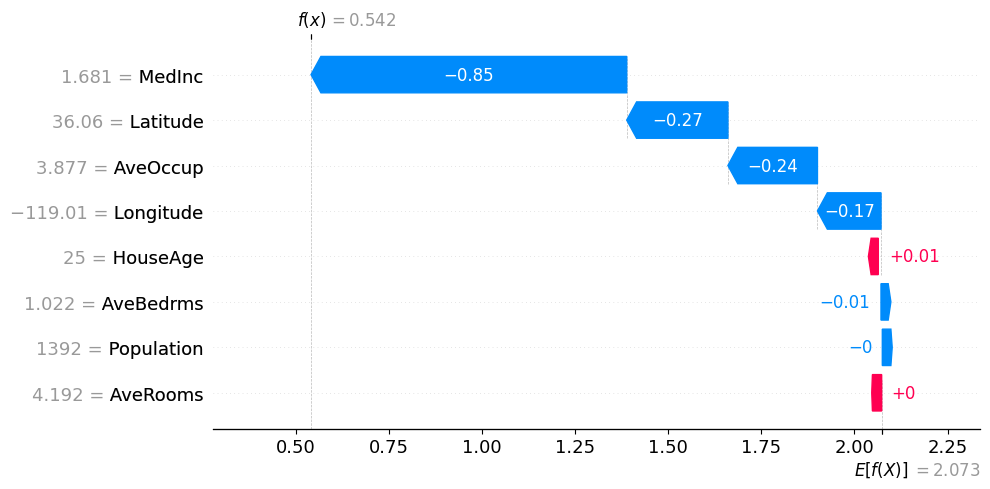

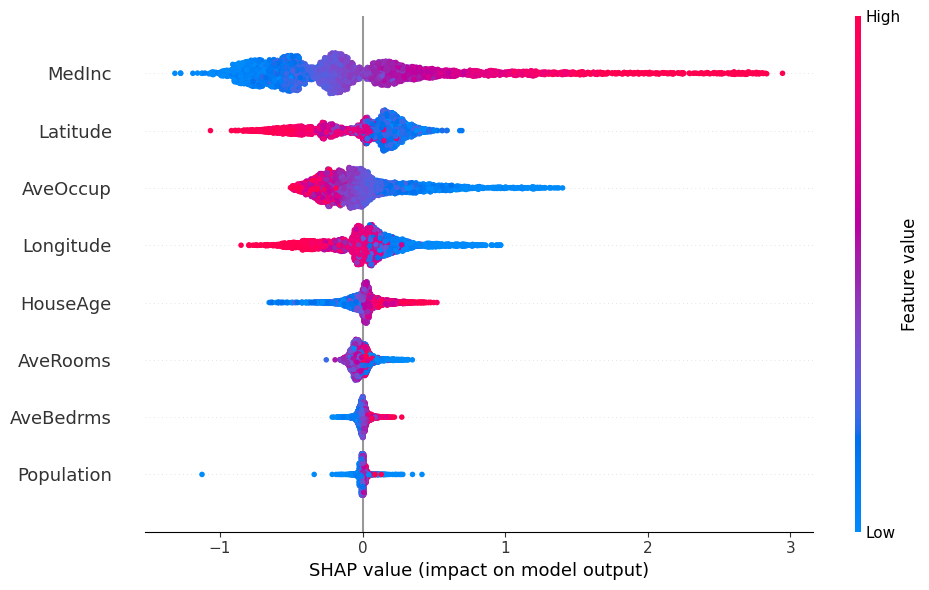

In [ ]:
#| echo: true
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap(X_test)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.gcf().set_size_inches(10, 5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.show()

Doing the same for LIME values, plotting the local importance of the features.

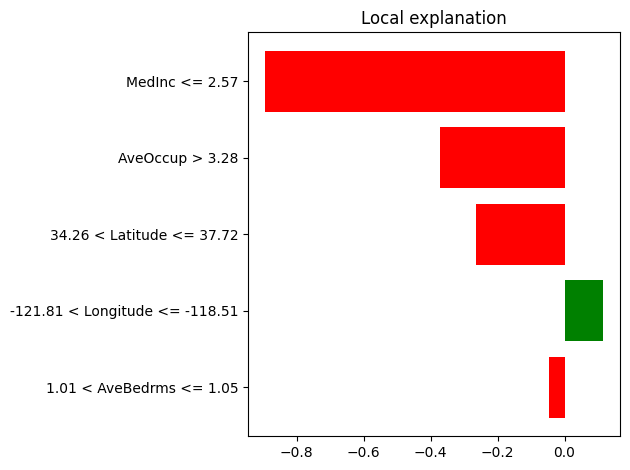

In [ ]:
#| echo: true
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['MedHouseValue'],
    mode='regression',
    random_state=42
)

exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[sample_idx],
    predict_fn=model.predict,
    num_features=5
)

plt.figure(figsize=(10, 5))
exp.as_pyplot_figure()
plt.tight_layout()
plt.show()